<a href="https://colab.research.google.com/github/Sg134-ch/Flyrank-ML-1/blob/main/work/notebooks/w02_ml_task_framing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-03 — Frame Your Lane as an ML Task

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [2]:
# Clone the repository (only if it isn't already cloned)
!git clone https://github.com/Sg134-ch/Flyrank-ML-1.git

# Move into the repository
%cd Flyrank-ML-1

# Verify that the dataset exists
import os
print("Current directory:", os.getcwd())
print("Dataset exists:", os.path.exists("data/raw/content_refresh_anonymized.csv"))

Cloning into 'Flyrank-ML-1'...
remote: Enumerating objects: 103, done.
remote: Counting objects: 100% (103/103), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 103 (delta 23), reused 77 (delta 13), pack-reused 0 (from 0)
Receiving objects: 100% (103/103), 1.86 MiB | 5.60 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/Flyrank-ML-1
Current directory: /content/Flyrank-ML-1
Dataset exists: True


## 1. My lane as an ML task (type)

*Classification, clustering, ranking, or scoring — which one, and why?*

# 1. My Lane as an ML Task

## Chosen Lane

**Content Refresh Prioritization**

## ML Task Type

This problem is primarily a **ranking** task.

Rather than making a simple yes/no prediction, the objective is to rank webpages according to how urgently they should be reviewed for content refresh. Higher-ranked pages are expected to have a greater likelihood of declining performance and therefore deserve earlier attention from SEO specialists.

Although the problem can also be framed as binary classification (declining vs. not declining), ranking better reflects the real business objective because content teams usually review only the highest-priority pages rather than every page in the dataset.

## 2. Target or proxy

*What would you predict? Where does that label come from — observed outcome or a defined rule?*

# 2. Target or Proxy

The starter dataset does not directly contain a "needs refresh" label. Instead, a proxy target is created using the historical performance trend.

The target variable is defined as:

- **1** → Page is labelled as **down**
- **0** → All other trend categories

This proxy represents webpages that have already experienced meaningful decline and provides historical examples from which the model can learn.

The target is intended for supervised learning and serves as an approximation of pages that may benefit from future content refresh.

In [3]:
import pandas as pd

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Create target column
df["target"] = (df["trend_direction"] == "down").astype(int)

df[["trend_direction","target"]].head(10)

,trend_direction,target
0,down,1
1,down,1
2,down,1
3,stable,0
4,down,1
5,down,1
6,down,1
7,stable,0
8,down,1
9,down,1


## 3. Success metric

*One metric you can defend. What number means 'good'?*

# 3. Success Metric

The primary success metric for this project is **Precision@50**.

Precision@50 measures the proportion of truly declining pages among the top 50 pages recommended by the model.

This metric is appropriate because content teams usually review only a limited number of pages. A model that correctly prioritizes the highest-risk pages is more valuable than one that simply achieves high overall accuracy.

Secondary evaluation metrics may include:

- Precision@20
- Recall
- F1 Score
- ROC-AUC (for binary classification evaluation)

However, Precision@50 best reflects the practical business decision.

## 4. The unit of analysis, as a real dataframe

*Load your lane's slice and show it: one row = one what?*

# 4. Unit of Analysis

Each row in the dataset represents **one webpage**.

The unit of analysis is therefore a single webpage together with its observable SEO characteristics.

Examples of available features include:

- Search impressions
- Click-through rate (CTR)
- Average ranking position
- Content age
- Days since last update
- Word count

In [4]:
columns = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count",
    "trend_direction",
    "target"
]

df[columns].head(10)

,content_age_days,days_since_last_update,impressions_90d,avg_position,ctr,word_count,trend_direction,target
0,187,20,3803,10.6,0.76,3221.0,down,1
1,445,25,15320,20.3,0.05,2481.0,down,1
2,141,20,12581,36.5,0.09,3515.0,down,1
3,463,22,11751,6.2,0.49,NaN,stable,0
4,263,14,19140,44.0,0.13,2803.0,down,1
5,147,20,3970,8.5,0.03,3080.0,down,1
6,90,20,20,7.0,0.00,3059.0,down,1
7,445,22,1724,21.2,0.06,NaN,stable,0
8,90,20,32574,46.0,0.09,3807.0,down,1
9,257,104,1240,4.9,0.16,NaN,down,1


## 5. Why ML beats a fixed rule here

*What makes the pattern too messy for an if-statement?*

# 5. Why ML Beats a Fixed Rule

A simple rule-based approach might recommend refreshing pages that satisfy conditions such as:

- More than 180 days since last update
- High impressions
- Low click-through rate

Although these rules are transparent, they cannot capture complex interactions among multiple variables.

Machine learning can simultaneously learn relationships between numerous observable signals including:

- Search visibility
- User engagement
- Ranking position
- Content freshness
- Historical performance

Rather than relying on manually chosen thresholds, the model discovers patterns directly from historical data and produces a ranked list of pages that are most likely to require review.

The model therefore serves as a decision-support system that helps SEO teams prioritize limited editorial resources more effectively.

In [5]:
features = [
    "content_age_days",
    "days_since_last_update",
    "impressions_90d",
    "avg_position",
    "ctr",
    "word_count"
]

print("Selected Features")

df[features].describe().round(2)

Selected Features


,content_age_days,days_since_last_update,impressions_90d,avg_position,ctr,word_count
count,30000.00,30000.00,30000.00,30000.00,30000.00,22301.00
mean,256.17,46.10,5200.37,16.34,0.51,3107.76
std,132.71,42.08,16838.02,15.22,3.28,1452.38
min,90.00,1.00,1.00,0.00,0.00,8.00
25%,132.00,20.00,81.00,6.20,0.00,2413.00
50%,236.00,20.00,731.00,10.80,0.07,2877.00
75%,333.00,104.00,3615.25,22.30,0.29,3666.00
max,564.00,373.00,517715.00,245.00,100.00,9546.00


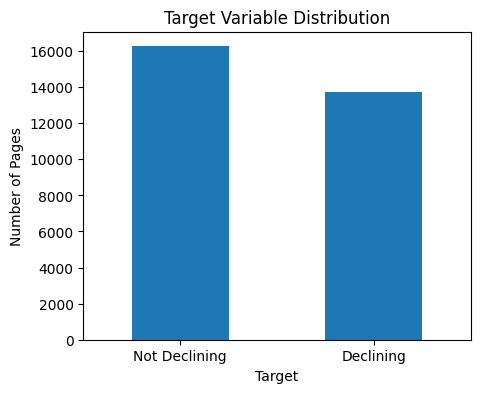

In [6]:
import matplotlib.pyplot as plt

target_counts = df["target"].value_counts()

plt.figure(figsize=(5,4))
target_counts.plot(kind="bar")
plt.title("Target Variable Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Pages")
plt.xticks([0,1],["Not Declining","Declining"],rotation=0)
plt.show()

# 6. Self-Check

Before submitting this assignment, I confirmed the following:

- ✅ I identified the appropriate machine learning task type.
- ✅ I defined a suitable target variable.
- ✅ I explained why the target is a proxy rather than a perfect label.
- ✅ I selected an evaluation metric that matches the business decision.
- ✅ I demonstrated the unit of analysis using the actual dataset.
- ✅ I explained why machine learning is preferable to a fixed rule.
- ✅ My notebook runs successfully from top to bottom.
- ✅ All code is reproducible using the starter dataset.
- ✅ My claims use careful language and do not imply causal relationships.